# Aula 4


# Camadas customizadas


### Eduardo Lobo Lustosa Cabral

## 1. Objetivos

Apresentar como criar uma camada customizada na forma de uma camada Lambda e usá-la em um modelo.

Apresentar como criar uma camada customizada na forma de classe de camadas do Keras e usá-la em um modelo.

Apresentar exemplos completos de uso de camadas customizadas incluindo o treinamento dos modelos.

### Importação das bilbiotecas básicas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.__version__)

2.19.0


## 2. Introdução

Existem inúmeras camadas disponíveis no TensorFlow/Keras. A lista é bem grande, sendo que as mais utilizadas são:

- Camadas de uso geral:

    - Input;
    - Dense;
    - Dropout;
    - Flatten;
    - Reshape;
    - Lambda;
    - BatchNormalization;
    - Concatenate.
    
    
- Camadas convolucionais:

    - Conv2D;
    - MaxPooling;
    - Conv2DTranspose;
    - GlobalAveragePooling.
    

- Camadas recorrentes:

    - SimpleRNN;
    - GRU;
    - LSTM.
    
    
- Camadas de ativações:

    - ReLu;
    - Sigmoid;
    - Softmax;
    - LeakyReLU;
    - ELU.
    
    
- Camadas de operações matemáticas:

    - Add;
    - Multiply;
    - Subtract.
    
    
A lista completa de camadas disponíveis no TensorFlow/Keras pode ser vista em https://www.tensorflow.org/api_docs/python/tf/keras/layers.

Apesar de existirem inúmeras camadas disponíveis no Keras, em alguns problemas é necessário criar novas camadas. Existem basicamente duas formas de customizar camadas no Keras:

- Uso de uma camada Lambda;
- Uso de uma camada na forma de classe do Keras.

Se for desejado uma camada customizada com cálculos não muito complexos, pode ser usada uma camada Lambda, onde é possível executar funções arbitrárias. Porém se os cálculos a serem realizados forem muito complexos e, principalmente, se a camada possuir parâmetros treináveis é necessário usar uma camada customizada na forma de classe.

## 3. Camada Lambda

Funções tipo Lambda consistem de uma estrutura natural da linguagem Python, que consistem de funções simples e restritas, que não precisam ter nome, definidas em geral por uma única linha de programação.

A ideia da função tipo Lambda do Python é recriada no Keras como sendo uma camada de uma RNA que realiza cálculos simples.

Uma camada tipo Lambda pode ser inserida em qualquer posição de uma RNA.

Existem vários exemplos de uso de camadas Lambda.


### 3.1 Camada para cálculo algébrico

No código a seguir é apresentada como configurar uma camada tipo Lambda que calcula o quadrado dos elementos do tensor de entrada da camada para um modelo de RNA Sequencial e para um modelo de RNA Functional do Keras.

In [ ]:
# Importa modelo sequencial e classe de camadas do Keras
from tensorflow.keras import models
from tensorflow.keras import layers

'''RNA sequencial'''
# Define RNA sequencial
rnaSeq = models.Sequential()

# Adiciona camada de entrada
rnaSeq.add(layers.Input(shape=(1,)))

# Adiciona camada Lambda em uma RNA sequencial
rnaSeq.add(layers.Lambda(lambda x: x**2))

print(rnaSeq.summary())

'''RNA funcional'''
# Adiciona camada Lambda em uma RNA funcional
x1 = layers.Input(shape=(1,))
square_layer = layers.Lambda(lambda x: x**2)
x2 = square_layer(x1)

# Cria RNA
rnaFunc = models.Model(inputs=x1, outputs=x2)

print(rnaFunc.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_9 (Lambda)               │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_10 (Lambda)              │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


- A sintaxe da camada Lambda é muito simples. Primeiramente define-se a variável a ser utlizada, que no caso é a variável `x`, e depois define-se o cálculo a ser realizado, que no caso é `x**2`.

- No caso da camada Lambda do modelo Functional, primeiramente deve-se intanciar um objeto da classe de camada tipo Lambda com a função desejada, para depois utilizá-la como uma camada.

- Note que `x1` é o tensor de entrada da camada Lambda no modelo funcional.


Outro exemplo de camada Lambda para relizar um cálculo simples é calcular o absoluto de uma variável. Nesse caso a camada Lambda é definida por:

In [ ]:
# Importa classe de camadas do Keras
from tensorflow.keras import layers

# Adiciona camada Lambda em RNA sequencial
rnaSeq.add(layers.Lambda(lambda x: tf.math.abs(x)))

rnaSeq.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_9 (Lambda)               │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_11 (Lambda)              │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Importante: somente funções do TensorFlow ou do Keras Backend podem ser usadas em uma camada Lambda.**

### 3.2 Camada de normalização de dados

Outro exemplo de uma camada Lambda é a normalização dos dados de entrada que pode ser realizada por uma camada da RNA no lugar de serem feitos em uma etapa anterior de pré-processamento, ou por um gerador de dados.

Uma camada Lambda para normalizar os dados de entrada pode ser vantajosa no caso de processamento de imagens, para economizar memória.

- Em uma imagem colorida no padrão RGB cada pixel consiste de três números inteiros de 8 bits.


- Para uma RNA processar uma imagem os valores dos pixels têm que ser normalizados, ou seja, devem ser transformados para valores reais entre 0 e 1.


- Um número real ocupa no mínimo 32 bits, ou seja, ocupa pelo menos 4 vezes mais memória do que um pixel da imagem original, exigindo, dessa forma, mais memória para armazenar os dados.


No código a seguir é mostrado um exemplo de como configurar uma RNA para uma tarefa de classificação binária com uma camada Lambda para normalizar os dados de entrada. Observe que a camada Lambda de normalização foi incluida após a camada `Input` que define a entrada da RNA, para facilitar definir a dimensão das entradas.

In [ ]:
img_size = (512, 512, 3)

# Instancia a rede
rna = models.Sequential()

# Adiciona camada de entrada para receber os dados de entrada
rna.add(layers.Input(shape=img_size))

# Adiciona camada Lambda para normalização
rna.add(layers.Lambda(lambda x: x/255.))

# Adiciona demais camadas convolucionais e densas
rna.add(layers.Conv2D(32, (3, 3), strides=1, activation='relu'))
rna.add(layers.MaxPooling2D((2, 2)))
rna.add(layers.Flatten())
rna.add(layers.Dense(1, activation='sigmoid'))

rna.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_12 (Lambda)              │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 510, 510, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2080800)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │     2,080,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081,697 (7.94 MB)

 Trainable params: 2,081,697 (7.94 MB)

 Non-trainable params: 0 (0.00 B)

- Essa RNA é do tipo sequencial e possui uma camada convolucional, uma camada de maxpooling e uma camada densa.

- Nesse exemplo a camada de saída possui somente um neurônio com função de ativação sigmoide.

- Antes da primeira camada densa tem-se a camada Flatten para ajustar a dimensão da saída da camada Maxpooling2D à entrada da camada Densa.


### 3.3 Cálculos mais complexos

Cálculos mais complexos podem ser realizados em uma camada Lambda. Um exemplo é uma camada que retorna a concatenação da parte positiva com o módulo da parte negativa da entrada.

In [ ]:
# Importa Keras Backend
import tensorflow.keras.backend as K

# Define função
def rectifier(x):
    pos = K.relu(x)
    neg = K.relu(-x)
    return K.concatenate([pos, neg], axis=1)

# Adiciona camada na RNA
rna.add(layers.Lambda(rectifier))

rna.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_12 (Lambda)              │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 510, 510, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2080800)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │     2,080,801 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_13 (Lambda)              │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081,697 (7.94 MB)

 Trainable params: 2,081,697 (7.94 MB)

 Non-trainable params: 0 (0.00 B)

O que a função rectifier está fazendo?

In [ ]:
# Define entrada
x = [np.linspace(-2.0, 3.0, num=5), np.linspace(-3.0, 1.0, num=5)]

# Converte entrada para tensor do TF
x = tf.convert_to_tensor(x, dtype=tf.float32)
print('x shape:', x.shape)

# Aplica função rectifier
y = rectifier(x)

# Apresenta entrada e saída
print('Entrada:\n', x.numpy(),'\n')
print('Saída:\n', y.numpy())

x shape: (2, 5)
Entrada:
 [[-2.   -0.75  0.5   1.75  3.  ]
 [-3.   -2.   -1.    0.    1.  ]] 

Saída:
 [[0.   0.   0.5  1.75 3.   2.   0.75 0.   0.   0.  ]
 [0.   0.   0.   0.   1.   3.   2.   1.   0.   0.  ]]


### 3.4 Limitação das camadas Lambda

Uma limitação importante das camadas tipo Lambda é que elas não possuem nenhum parâmetro treinável. Dessa forma ela não é capaz de perceber alterações nos dados de entrada.

Camadas Lambda devem ser usadas somente para cálculos pré-definidos e em geral não muito complexos.

## 4. Exemplo de RNA com camadas Lambdas

Para apresentar um exemplo mais realista de uso de camadas Lambdas, vamos desenvolver um modelo para resolver uma tarefa de classificação multiclasse para classificar os dígitos do conjunto de dados MNIST.

Como de costume, sendo as imagens de dígitos da MNIST de pequenas dimensões (28x28) e em tons de cinza, podemos usar uma RNA com somente camadas densas.

Nesse exemplo o processamento das imagens será totalmente realizado dentro da RNA, incluindo o redimensionamento e normalização das imagens.

Para processar as imagens temos que ter camadas para realizar as seguintes operações:

1. Normalização dos pixels transformando-os em números reais com valores entre 0.0 e 1.0.
2. Redimensionamento das imagens de dimensão 28x28 para tranformá-las em vetores com 784 elementos.


### 4.1 Configuração da RNA

Para realizar essa tarefa vamos usar uma RNA com uma camada densa intermediária e uma camada densa de saída. Além disso, vamos usar uma função de ativação customizada na camada intermediária que calcula o valor absoluto dos estados do neurônios.

A codificação dessa RNA é realizada na célula abaixo.

In [ ]:
# Instancia modelo sequencial
rna = models.Sequential()

# Redimensiona imagens de entrada
rna.add(layers.Flatten(input_shape=(28,28)))

# Normaliza pixels
rna.add(layers.Lambda(lambda x: x/255.))

# Adiciona camada densa intermediária sem função de ativação
rna.add(layers.Dense(128))

# Inclui função de ativação "valor absoluto"
rna.add(layers.Lambda(lambda x: tf.math.abs(x)))

# Inclui camada de saída
rna.add(layers.Dense(10, activation='softmax'))

# Sumario da rede
rna.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_14 (Lambda)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_15 (Lambda)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

- Nota-se que a camada `Faltten()` realiza o redimensionamento das imagens para transformá-las em vetores.

- Se for necessário redimensionar uma imagem alterando o número de seus pixles, o Keras fornece a camada `tf.keras.layers.experimental.preprocessing.Resizing(height, width, interpolation="bilinear", name=None)`.

### 4.2 Conjunto de dados

Vamos carregar o conjunto de dados de dígitos MNIST diretamento de Keras, conforme realizado na célula a seguir.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Dimensão dos dados de entrada de treinamento =', x_train.shape)
print('Dimensão dos dados de entrada de teste =', x_test.shape)
print('Dimensão dos dados de saída de treinamento =', y_train.shape)
print('Dimensão dos dados de saída de teste =', y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dimensão dos dados de entrada de treinamento = (60000, 28, 28)
Dimensão dos dados de entrada de teste = (10000, 28, 28)
Dimensão dos dados de saída de treinamento = (60000,)
Dimensão dos dados de saída de teste = (10000,)


### 4.3 Compilação da RNA

Vamos compilar a RNA da seguinte forma:

- Otimizador: Adam
- Taxa de aprendizado: 0,001
- Função de custo: "sparse categorical crossentropy"
- Metrica: "sparse categorical accuracy"

Observe que a função de custo utilizada nesse problema de classificação multiclasse é a "sparse categorical crossentropy" em razão da saídas estarem na forma de números inteiros e não de vetores "one-hot". Contudo, nota-se que usar essa forma de saídas e essa função de custo é bem menos eficiente computacionalmente do que codificar as saídas em vetores "one-hot" e usar a função de custo "categorical_crossentropy".

No caso das saídas de um problema de classificação muticlasse estarem no formato de categorias (números inteiros), então, é mais eficiente computacionalmente utilizar a métrica "sparse categorical accuracy" no lugar da "acuracy". A mética "accuracy" é mais adequada para saídas na forma de vetores "one_hot".

In [ ]:
# Importa classe dos otimizadores
from tensorflow.keras import optimizers

# Instância otimizador
adam= optimizers.Adam(learning_rate=0.001)

# Compilação da RNA
rna.compile(optimizer=adam, loss=['sparse_categorical_crossentropy'], metrics=['sparse_categorical_accuracy'])

### 4.4 Treinamento da RNA

Para treinar a RNA vamos utilizar 30 épocas e lotes de 1024 exemplos.

In [ ]:
results = rna.fit(x_train, y_train, batch_size=1024, epochs=30, verbose=1, validation_data=(x_test, y_test))

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 1.2131 - sparse_categorical_accuracy: 0.6668 - val_loss: 0.3148 - val_sparse_categorical_accuracy: 0.9176
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2952 - sparse_categorical_accuracy: 0.9205 - val_loss: 0.2181 - val_sparse_categorical_accuracy: 0.9401
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2090 - sparse_categorical_accuracy: 0.9425 - val_loss: 0.1732 - val_sparse_categorical_accuracy: 0.9525
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1620 - sparse_categorical_accuracy: 0.9560 - val_loss: 0.1468 - val_sparse_categorical_accuracy: 0.9583
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1336 - sparse_categorical_accuracy: 0.9636 - val_loss: 0.1310 - val_sparse_categorical_accuracy: 0.9636
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1166 - sparse_categorical_accuracy: 0.9680 - val_loss: 0.1147 - val_sparse_categorical_accuracy: 0.9656
Epoch 7/30
59/5

Resultados do processo de treinamento.

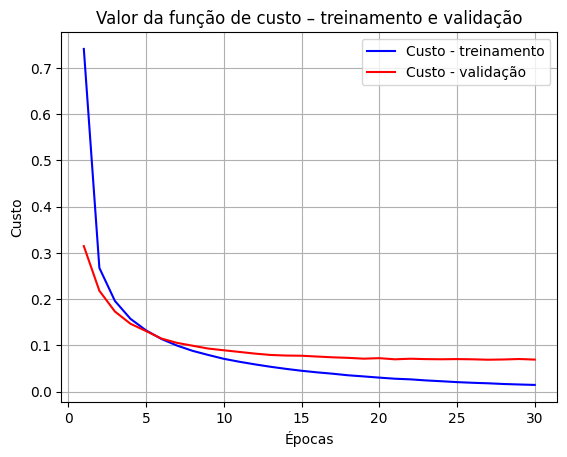

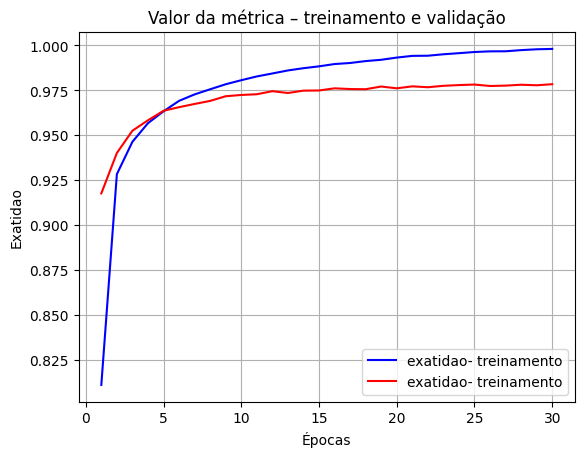

In [ ]:
def plot_train(history):# Salva treinamento na variável history para visualização
    history_dict = history.history

    # Salva custos, métricas e epocas em vetores
    custo = history_dict['loss']
    acc = history_dict['sparse_categorical_accuracy']
    val_custo = history_dict['val_loss']
    val_acc = history_dict['val_sparse_categorical_accuracy']

    # Cria vetor de épocas
    epocas = range(1, len(custo) + 1)

    # Gráfico dos valores de custo
    plt.plot(epocas, custo, 'b', label='Custo - treinamento')
    plt.plot(epocas, val_custo, 'r', label='Custo - validação')
    plt.title('Valor da função de custo – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('Custo')
    plt.grid()
    plt.legend()
    plt.show()

    # Gráfico dos valores da métrica
    plt.plot(epocas, acc, 'b', label='exatidao- treinamento')
    plt.plot(epocas, val_acc, 'r', label='exatidao- treinamento')
    plt.title('Valor da métrica – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('Exatidao')
    plt.grid()
    plt.legend()
    plt.show()

plot_train(results)

### 4.5 Avaliação da RNA

Para avaliar o desempenho da RNA vamos calcular a função de custo e a métrica e também calcular as saídas previstas e fazer o gráfico das saídas reais e previstas para poder compará-las.

In [ ]:
# Calcula função de custo e métrica
rna.evaluate(x_train, y_train)
rna.evaluate(x_test, y_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0133 - sparse_categorical_accuracy: 0.9982
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0793 - sparse_categorical_accuracy: 0.9758


[0.06933055073022842, 0.9783999919891357]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


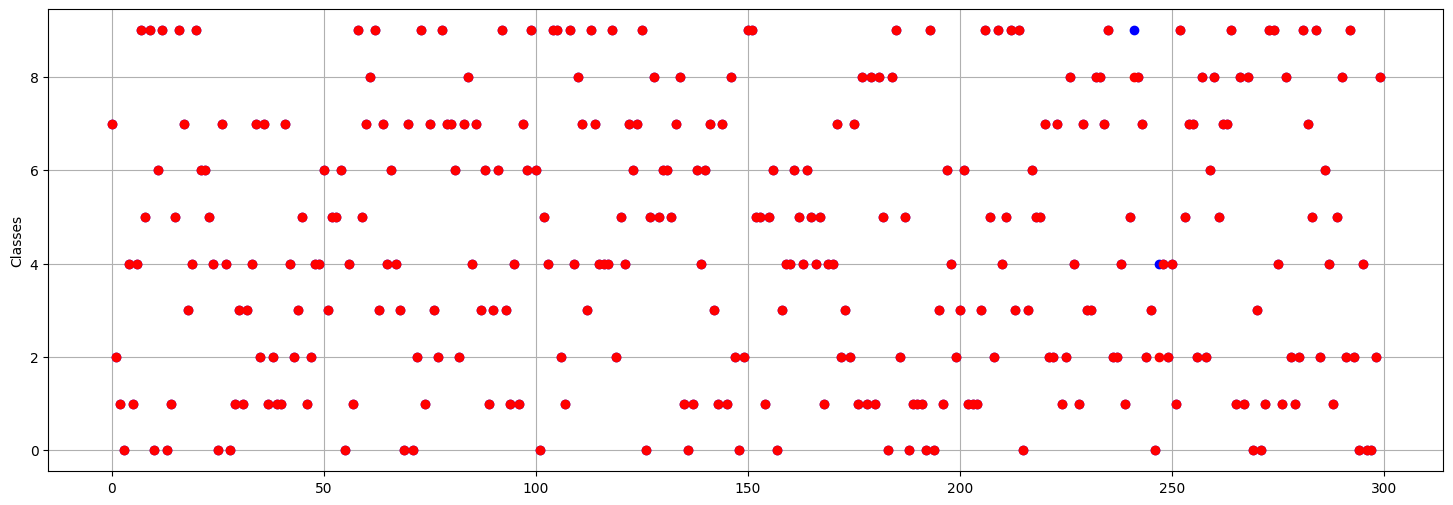

In [ ]:
# Calcula saídas previstas
y_prev = rna.predict(x_test)

# Indentifa classe prevista
class_prev = np.argmax(y_prev, axis=1)

# Gráfico dos resultados
#plt.scatter(x, y)
plt.figure(figsize=(18,6))
plt.plot(y_test[:300], 'bo', label='Saídas reais')
plt.plot(class_prev[:300], 'ro', label='Saídas previstas')
plt.ylabel('Classes')
plt.grid()
plt.show()

Nota-se que os resultados obtidos pela RNA são execelentes, nesses 150 exemplos de teste somente um foi classificado errado.

**Que tal comparar essa função de ativação (valor absoluto) com a função ReLu?**

## 5. Camada customizada na forma de classe

Camadas customizadas podem ser criadas na forma de classes.

As vantagens de usar uma camada customizada na forma de classe são as seguintes:

- A camada pode possuir parâmetros treináveis;
- Pode-se realizar operações que não são possíveis de realizar em uma camada Lambda.

Ao criar uma camada customizada na forma de classe, ela deve herdar as propriedades da classe de camadas do Keras. Para fazer isso, basta passar como parâmetro ao criar a nova classe de camada, a classe de camada do Keras (`Layers`).

Ao herdar as propriedades da classe de camadas do keras, é possível criar camadas complexas totalmente customizadas.

Mais detalhes sobre camadas customizadas do Keras pode ser obtida em
https://www.tensorflow.org/api_docs/python/tf/keras/layers/Layer


### 5.1 Estrutura das camadas do Keras

No Keras cada item de um modelo (RNA) é uma camada $\to$ não é possível realizar nenhuma operação dentro de um modelo que não seja realiza por uma camada.

Uma camada do keras é uma classe que encapsula "estados" e "cáculos" para realizar o processo proposto.

- Estados:

    - O Keras define os parâmetros de uma camada como sendo os seus estados; nota-se que essa definição é diferente da que usamos quando vimos a estrutura das redes neurais;
    - Os parâmetros podem ser treináveis para o modelo se ajustar aos dados, ou não treináveis e usados para calcular alguma função específica.
  
- Cálculos:

    - Os cálculos da camada são as operações necessária para calcular a propagação para frente na camada, ou seja, são os cálculos necessários para transformar um lote de dados de entrada em um lote de dados na saída da camada (ativações da camada).
    
    
Com essa definição, os estados e cálculos de uma camada tipo Densa são os seguintes:

- Estados:
    
    - Kernel (peso das ligações): tensor W
    - Viéses dos neurônios: tensor b
    
- Cálculos:

    - $y = Wx + b$, onde $x$ é o tensor de entrada da camada e $y$ é o tensor de saída da camada.
    - Observa-se que a função de ativação não está necessarimente incluída nos cálculos de uma camada.
    

### 5.2 Estrutura da classe de camadas do Keras

A classe de camadas do Keras tem uma estrutura bem determinada.

Para criar uma camada customizada na forma de classe temos que criar uma classe que herda as propriedades da classe de camadas do Keras, que é a classe `Layers`.

Uma classe de camadas customizadas do Keras precisa de ter em geral 3 métodos:

- Método `__init__(self, units)` $\to$ serve para inicializar um objeto da classe, definir parâmetros e variáveis internas. Esse método recebe como argumentos de entrada as variáveis primitivas da classe (`self`) e o número de unidades da camada (`units`).
    
    
- Método `build(self, input_shape)` $\to$ é executado quando uma instância da classe é criada. Esse método é usado para inicializar parâmetros e outros elementos necessários para criar um objeto da classe. Esse método recebe como argumentos de entrada as variáveis primitivas da classe (`self`) e a dimensão da entrada (`input_shape`). Se a camada não possuir parâmetros terináveis esse método não é necessário.


- Método `call(self, inputs)` $\to$ realiza os cálculos definidos na camada. Esse método é chamado durante o treinamento e previsão do modelo para calcular as saídas da camada. Esse método recebe como argumentos de entrada as variáveis primitivas da classe (`self`) e os dados de entrada (`input`); e retorna as saídas da camada. Esse método tem que estar presente obrigatoriamente.

No código abaixo é criada a classe de camada tipo Densa, contudo simplificada em relação à equivalente do Keras, portanto vamos chamá-la de camada `SimpleDense`.

In [ ]:
# Importa classe de camadas do Keras
from tensorflow.keras.layers import Layer

# Define camada customizada SimpleDense herdando propriedades da classe "Layer" do Keras
class SimpleDense(Layer):

    # Método para inicialização da classe
    def __init__(self, units=32):
        # Iniciliza classe
        super(SimpleDense, self).__init__()

        # Inicializa número de unidades
        self.units = units

    # Método executado quando é instanciado um objeto da classe
    def build(self, input_shape):
        # Instancia objeto para calcular valores iniciais para o kernel (pesos das ligações)
        w_init = tf.random_normal_initializer()

        # Inicializa kernel como parâmetro treinável
        self.w = self.add_weight(initializer=w_init, shape=(input_shape[-1], self.units), dtype='float32', trainable=True)

        # Instancia objeto para calcular valores inciais para os viéses
        b_init = tf.zeros_initializer()

        # Inicializa os viéses como parâmetros treináveis
        self.b = self.add_weight(initializer=b_init, shape=(self.units,), dtype='float32', trainable=True)

    # Define cálculos executados pela camada
    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b

- Método `__init__()`:

    - Inicialização da classe é feita pela função `super()`, herdada da classe `Layer`.
    - A variável `self.units` é o número de unidades (neurônios) da camada; no exemplo, o padrão é definido como sendo 32, assim, se não for passado um número diferente a camada terá 32 unidades.
    - Esse método pode receber outras variáveis necessárias para a operação da camada.
    
    
- Método `build()`:

    - Uma camada deve ter todos os seus parâmetros treináveis e não treináveis inicializados $\to$ o TensorFlow possui várias funções para inicializar os parâmetros (ver as possibilidades em https://www.tensorflow.org/api_docs/python/tf/keras/initializers).
    - Nesse exemplo o kernel é inicializado com números aletórios de distribuição normal, com média zero e desvio padrão igual a um, usando a função `tf.random_normal_initializer()`. Os viéses são inicializados com zeros usando a função `tf.zeros_initializer()`.
    - Variável `self.w` é o tensor com os pesos das ligações dos neurônios, que deve ser criado como sendo `tf. Variable` para poder ser modificado no treinamento e passado após o treinamento do modelo.
    - `self.w` é um tensor com dimensão `input_shape[-1] x self.units`, onde `input_shape[-1]` seria a dimensão da saída da camada anterior, que no momento de instanciação do objeto de uma camada pode não ser ainda conhecido.
    - Variável `self.b` é o tensor de viéses dos neurônios, que também deve ser criado como sendo `tf.Variable` para poder ser modificado no treinamento.
    - Dimensão de `self.b` é igual ao número de unidades da camada (`self.units`).
    - Tanto `self.w` como `self.b` são definidos como sendo `trainable=True` para poderem ser modificados durante o treinamento do modelo.
    
    
- Método `call()`:

    - Realiza os cálculos da propagação para frente da camada.
    - Como `self.w` e `inputs` são tensores TF, então, deve-se usar a função `tf.matmul()` para poder multiplicá-los.
    
Observa-se que se uma classe possui parâmetros não treináveis e eles não são modificados na operação da camada, então, esses parâmetros podem ser criados como sendo `tf.constant`.
    
Na célula abaixo é mostrado um código com um exemplo de uso da camada `SimpleDense`, de forma a verificar o seu funcionamento.

In [ ]:
# Instanciação da camada SimpleDense com um único neurônio
my_dense = SimpleDense(units=5)

# Entrada da camada com 2 elementos
x = tf.ones((3,2))

# Calcula saída da camada
y = my_dense(x) #This call will initialize the weights

# Resultados
print('Pesos iniciais da camada:\n', my_dense.variables[0],'\n')
print('Viés inicial da camada:\n', my_dense.variables[1],'\n')
print('Resultado do cálculo da saída:', y.numpy())

Pesos iniciais da camada:
 <Variable path=simple_dense_3/variable_2, shape=(2, 5), dtype=float32, value=[[-0.04474378 -0.05393055 -0.04983367 -0.06244649  0.03525655]
 [-0.17043816  0.07183071 -0.1077159   0.04965163  0.05288098]]> 

Viés inicial da camada:
 <Variable path=simple_dense_3/variable_3, shape=(5,), dtype=float32, value=[0. 0. 0. 0. 0.]> 

Resultado do cálculo da saída: [[-0.21518193  0.01790016 -0.15754957 -0.01279486  0.08813753]
 [-0.21518193  0.01790016 -0.15754957 -0.01279486  0.08813753]
 [-0.21518193  0.01790016 -0.15754957 -0.01279486  0.08813753]]


- A variável `nome_da_camada.variables` consiste de uma lista com os parâmetros da camada.

- Para visualizar os parâmetros de uma camada basta executar `nome_da_camada.variables`.

- Os resultados da célula acima apresentam os parâmetros inicializados quando um objeto da camada é instanciado $\to$ quando treinamos um modelo com essa camada os valores dos seus parâmetros são ajustados à transfromação desejada nos dados.  

### 5.3 Camada densa customizada na forma de classe

A camada `SimpleDense` criada para exemplificar a estrutura da classe de camadas do Keras não possui função de ativação $\to$ isso pode ser contornado usando uma camada de ativação, mas não seria a forma ideal. O ideal é incluir a ativação dentro da camada.

Para incluir uma função de ativação na camada `SimpleDense` os métodos `__init__()` e `call()` devem ser modificados, conforme mostrado na célula abaixo.

In [ ]:
# Importa classe de camadas do Keras
from tensorflow.keras.layers import Layer

# Define camada customizada SimpleDense herdando propriedades da classe "Layer" do Keras
class SimpleDense(Layer):

    # Método para inicialização da classe
    def __init__(self, units=32, activation=None):
        # Inicializa classe
        super(SimpleDense, self).__init__()

        # Inicializa número de unidades
        self.units = units

        # Define função de ativação
        self.activation = tf.keras.activations.get(activation)

    # Método executado quando é instanciado um objeto da classe
    def build(self, input_shape):
        # Instância objeto par calacular valores iniciais para o kernel (pesos das ligações)
        w_init = tf.random_normal_initializer()

        # Inicializa kernel como parâmetro treinável
        self.w = self.add_weight(initializer=w_init, shape=(input_shape[-1], self.units), dtype='float32', trainable=True)

        # Instância objeto para calcular valores inciais para os viéses
        b_init = tf.zeros_initializer()

        # Inicializa os viéses como parâmetros treináveis
        self.b = self.add_weight(initializer=b_init, shape=(self.units,), dtype='float32', trainable=True)

    # Define cálculos executados pela camada usando a função de ativação selecionada
    def call(self, inputs):
        z = tf.matmul(inputs, self.w) + self.b
        a = self.activation(z)
        return a

- A função de ativação selecionada para a camada deve ser recebida pelo método `__init__()`. Para isso tem-se:

    - Se `activation=None`, então, não é aplicada nenhuma função de ativação na camada, na prática isso representa usar uma função de ativação linear.
    - O padrão definido para a função de ativação é `None`, ou seja nenhuma função de ativação é usada.
    - A variável `activation` deve receber uma string com o nome da função de ativação desejada, ou de um objeto de uma classe de ativação.
    - Ver lista completa de funções de ativação do Keras em https://www.tensorflow.org/api_docs/python/tf/keras/activations).
    - Funções de ativações também podem ser usadas na forma de classe no Keras. Nesse caso as funções de ativações são consideradas camadas no Keras.
    
    
- O método `call()` deve ser modificado para aplicar a função de ativação no valor retornado no cálculo da camada. Para isso basta incluir a função `self.activation()` definida na instanciação do objeto, realizada pelo método `__init__()`.

A célula abaixo instância um objeto da classe `SimpleDense` e o executa para verificar o seu funcionamento.

In [ ]:
# Instanciação da camada SimpleDense com um único neurônio
my_dense = SimpleDense(units=5, activation='relu')

# Entrada da camada com 2 elementos
x = tf.ones((3,2))

# Calcula saída da camada
y = my_dense(x)

# Resultados
print("Número de parâmetros da camada:", len(my_dense.weights))
print("Número de parâmetros treináveis:", len(my_dense.trainable_weights),'\n')
print('Pesos iniciais da camada:\n', my_dense.variables[0],'\n')
print('Viés inicial da camada:\n', my_dense.variables[1],'\n')
print('Resultado do cálculo da saída:', y.numpy())

Número de parâmetros da camada: 2
Número de parâmetros treináveis: 2 

Pesos iniciais da camada:
 <Variable path=simple_dense_4/variable_4, shape=(2, 5), dtype=float32, value=[[ 0.06663194 -0.03071116  0.12100147  0.02273441  0.04654133]
 [-0.06123322  0.02250105  0.06089106 -0.04787199  0.02024184]]> 

Viés inicial da camada:
 <Variable path=simple_dense_4/variable_5, shape=(5,), dtype=float32, value=[0. 0. 0. 0. 0.]> 

Resultado do cálculo da saída: [[0.00539872 0.         0.18189254 0.         0.06678317]
 [0.00539872 0.         0.18189254 0.         0.06678317]
 [0.00539872 0.         0.18189254 0.         0.06678317]]


### 5.4 Camada customizada sem parâmetros

Algumas camadas não possuem parâmetros, assim, essas camadas não precisam do método `build()`, que serve para inicilizar parâmetros. Para exemplificar isso, vamos criar uma camada customizada na forma de classe para realizar o pré-processamento de imagens.

As operações de pré-processamento dessa camada são as seguintes:

1. Normalização dos pixels transformando-os em números reais com valores entre 0.0 e 1.0.
2. Redimensionamento das imagens para tranformá-las em vetores.

Observe que essa camada não possui unidades, parâmetros treináveis e nem função de ativação.

In [ ]:
# Importa classe de camadas do Keras
from tensorflow.keras.layers import Layer

# Define camada customizada PreProcess herdando propriedades da classe "Layer" do Keras
class PreProcess(Layer):

    # Método para inicialização da classe
    def __init__(self, output_dim):
        # Inicializa classe
        super(PreProcess, self).__init__()

        # Define número de elementos do vetor de saída
        self.output_dim = output_dim

    # Redimensiona e normaliza imagem
    def call(self, inputs):
        # Transforma pixels em tipo float32
        out = tf.cast(inputs, dtype=tf.float32)
        # Redimensiona e normaliza pixels
        out = tf.reshape(out, (tf.shape(inputs)[0], self.output_dim))/255.
        return out

- Observe que o método `__init__()` não precisa receber o argumento `units`.
- O número de elementos do vetor no qual a imagem é redimensionada não pode ser obtido da própria dimensão das imagens de entrada, porque ao criar a RNA essa dimensão não é conhecida.

Na célula abaixo é instanciada e executada uma camada da classe PreProcess para verificar o seu funcionamento.

In [ ]:
# Instanciação da camada PreProcess
preproc = PreProcess(output_dim=6)

# Entrada da camada com 2 elementos e dimensão 3x2
x = tf.ones((2,3,2))

# Calcula saída da camada
y = preproc(x)

# Resultados
print("Número de parâmetros da camada:", len(preproc.weights))
print('Dimensão da saída da camada:', y.shape)
print('Resultado do cálculo da saída:\n', y.numpy())

Número de parâmetros da camada: 0
Dimensão da saída da camada: (2, 6)
Resultado do cálculo da saída:
 [[0.00392157 0.00392157 0.00392157 0.00392157 0.00392157 0.00392157]
 [0.00392157 0.00392157 0.00392157 0.00392157 0.00392157 0.00392157]]


### 5.5 Camada customizada com parâmetros não treináveis

Algumas camadas podem ter parâmetros não treináveis.

Além dos parâmetros treináveis, é possível adicionar parâmetros não treináveis em uma camada.

Os parâmetros não treináveis não são alterados para ajustar aos dados durante o treinamento.

No código abaixo é mostrado como criar uma camada que realiza a soma de seu estado interno com a soma das colunas do tensor de entrada, além de mostrar o seu funcionamento.

In [ ]:
# Define classe de camada ComputeSum
class ComputeSum(Layer):
    # Inicializa objeto da classe
    def __init__(self, input_dim):
        # Incialização
        super(ComputeSum, self).__init__()

        # Incializa estado interno da camada com valor zero e como sendo parâmetro não treinável
        self.total = tf.Variable(initial_value=tf.zeros((input_dim,)), trainable=False)

    # Define cálculo realizado pela camada
    def call(self, inputs):
        # Adiciona a entrada ao valor do estado interno da camada
        self.total.assign_add(tf.reduce_sum(inputs, axis=0))
        return self.total

''' Operação da camada '''

# Define tensor de entrada da camada
x = tf.ones((2, 3))
print('Entrada:\n', x.numpy())

# Instância objeto da camada
my_sum = ComputeSum(3)

# Calcula saída da camada
y = my_sum(x)
print('Saida 1:', y.numpy())

# Calcula saída da camada novamente
y = my_sum(x)
print('Saída 2:', y.numpy())

# Mostra parâmetros da camada
print("\nNúmero de parâmetros da camada:", len(my_sum.weights))
print("Número de parâmetros não treináveis:", len(my_sum.non_trainable_weights))
print("Parâmetros treináveis:", my_sum.trainable_weights)

Entrada:
 [[1. 1. 1.]
 [1. 1. 1.]]
Saida 1: [2. 2. 2.]
Saída 2: [4. 4. 4.]

Número de parâmetros da camada: 0
Número de parâmetros não treináveis: 0
Parâmetros treináveis: []


Observa-se que o parâmetro da camada foi criado no método `__init__()`, dispensando a necessidade do método `build()`. Porém, isso pode não ser muito adequado. Ao criar uma camada recomenda-se adiar a criação dos seus parâmetros até que a dimensão das entradas seja conhecida. A camada `ComputeSum` acima recebeu o argumento `input_dim` que é usado para calcular a dimensão do seu parâmetro (estado interno) no método `__init__()`.

Em muitos casos, pode-se não se conhecer com antecedência a dimensão das entradas e, assim, é interessante postergar a criação dos parâmetros quando essa dimensão for conhecida, o que ocorre depois de instanciar a camada. Para fazer isso, é recomendado criar os parâmetros de uma camada no método `build(self, inputs_shape)`.

No código abaixo é realizada essa alteração na camada `ComputeSum`.

In [ ]:
# Define classe de camada ComputeSum
class ComputeSum2(Layer):
    # Método para inicializar objeto da classe
    def __init__(self):
        # Incialização
        super(ComputeSum2, self).__init__()

    # Método para criar objeto da classe e inicializar parâmetros
    def build(self, input_shape):
        # Incializa estado interno da camada com valor zero e como sendo parâmetro não treinável
        self.total = tf.Variable(initial_value=tf.zeros(input_shape[-1]), trainable=False)

    # Define cálculo realizado pela camada
    def call(self, inputs):
        # Adiciona a entrada ao valor do estado interno da camada
        self.total.assign_add(tf.reduce_sum(inputs, axis=0))
        return self.total

''' Operação da camada '''

# Define tensor de entrada da camada
x = tf.ones((2, 3))
print('Entrada:\n', x.numpy())

# Instância objeto da camada
my_sum2 = ComputeSum2()

# Calcula saída da camada
y = my_sum2(x)
print('Saida 1:', y.numpy())

# Calcula saída da camada novamente
y = my_sum2(x)
print('Saída 2:', y.numpy())

Entrada:
 [[1. 1. 1.]
 [1. 1. 1.]]
Saida 1: [2. 2. 2.]
Saída 2: [4. 4. 4.]


- Observa-se que usar uma dimensão com valor `-1` representa no TensorFlow que não conhecemos nesse momento o seu valor.

### 5.6 Camadas compostas

Muitas operações interessantes são implementadas pela composição de camadas existentes. Por exemplo, cada bloco residual de uma rede ResNet é uma composição de convoluções, normalização de bateladas e um atalho.

Camadas podem ser inseridas dentro de outras camadas.

Se for atribuida uma instância de uma camada como um atributo de outra camada, a camada externa é capaz de rastrear e atualizar os parâmetros da camada interna.

Recomenda-se definir as subcamadas no método `__init__()`, para permitirem que sejam construídas quando a camada externa for também construída.

Como exemplo de criar uma camada customizada composta por várias subcamadas, vamos criar um bloco residual composto por camadas densas no lugar de camadas convolucionais.

Na Figura 1 é apresentado um esquema desse bloco (`ResidualDense`) que iremos criar na forma de uma camada customizada.

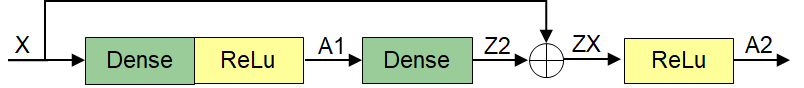

(ResidualDense.png)

<center>Figura 1 - Esquema da camada customizada ResidualDense.</center>
<br>

**Ressalta-se que o número de neurônios das duas camadas densas deve ser igual ao número de elementos do vetor de entrada do bloco, de forma que a entrada X possa ser adicionada à variável Z2.**

In [ ]:
# Define classe ResidualDense de camada
class ResidualDense(Layer):
    # Método para inicialização da classe
    def __init__(self, units=32, activation=None):
        # Inicializa classe
        super(ResidualDense, self).__init__()

        # Inicializa número de unidades
        self.units = units

        # Define subcamadas do bloco
        self.dense1 = layers.Dense(units=self.units)
        self.dense2 = layers.Dense(units=self.units)
        self.add = layers.Add()

        # Define função de ativação
        self.activation = tf.keras.activations.get(activation)

    # Define cálculos executados pela camada usando as camadas instanciadas no métotod __inite__()
    # e a função de ativação selecionada
    def call(self, inputs):
        z1 = self.dense1(inputs)
        a1 = self.activation(z1)
        z2 = self.dense2(a1)
        zx = self.add([inputs, z2])
        a2 = self.activation(zx)

        return a2

- Observe que para criar essa classe de camada não foi necessário usar o método `biuld()`, porque ao definirmos as camadas do bloco no método `__init__()` os seus parâmetros já são inicializados.

- Observa-se que usamos duas camadas densas `self.dense1` e `self.dense2` para termos duas camadas independentes com parâmetros diferentes. Se tivesse sido inicializada somente uma camada densa no método `__init__()`, as duas camadas densas do método `call()` compartilhariam os mesmos parâmetros, ou seja, seriam a mesma camada.

Na célula abaixo um bloco residual dense (`res_block`) é instanciado e testado.

In [ ]:
# Define tensor de entrada da camada
x = tf.ones((2, 5))
print('Entrada:\n', x.numpy(),'\n')

# Instância camada da classe ResidualDense
res_block = ResidualDense(units=5, activation='relu')

# Calcula saída da camada
y = res_block(x)
print('Saida:', y.numpy())

# Parâmetros da camada
print("\nNúmero de parâmetros da camada:", len(res_block.weights))
print("Número de parâmetros treináveis:", len(res_block.trainable_weights),'\n')
print("Pesos da 1a camada densa:\n", res_block.variables[0],'\n')
print("Viéses da 1a camada densa:\n", res_block.variables[1],'\n')
print("Pesos da 2a camada densa:\n", res_block.variables[2],'\n')
print("Viéses da 2a camada densa:\n", res_block.variables[3])

Entrada:
 [[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]] 

Saida: [[0.61742437 1.6996546  0.80400854 0.8752762  1.6857506 ]
 [0.61742437 1.6996546  0.80400854 0.8752762  1.6857506 ]]

Número de parâmetros da camada: 4
Número de parâmetros treináveis: 4 

Pesos da 1a camada densa:
 <Variable path=residual_dense/dense_3/kernel, shape=(5, 5), dtype=float32, value=[[ 0.07526171  0.20636761  0.03307366  0.11904877  0.39710212]
 [ 0.4458077   0.5449016   0.02296805 -0.18439126 -0.4592104 ]
 [ 0.22702885  0.7462671  -0.2665921   0.23381722 -0.48659763]
 [-0.20174748 -0.7393586   0.581301   -0.05648792  0.6488724 ]
 [ 0.6134888  -0.6353395  -0.34540242 -0.20519805  0.15684998]]> 

Viéses da 1a camada densa:
 <Variable path=residual_dense/dense_3/bias, shape=(5,), dtype=float32, value=[0. 0. 0. 0. 0.]> 

Pesos da 2a camada densa:
 <Variable path=residual_dense/dense_4/kernel, shape=(5, 5), dtype=float32, value=[[-0.5347078   0.56904244 -0.03894311 -0.09206891  0.40297806]
 [ 0.42052197  0.15818614 -0.164

- **Ressalta-se novamente que o número de neurônios das duas camadas densas deve ser igual ao número de elementos do vetor de entrada do bloco, de forma que a entrada X possa ser adicionada à variável Z2.**

## 6. Exemplo de RNA com camadas customizadas na forma de classe

Para apresentar um exemplo de uso de camadas customizadas na forma de classe, vamos desenvolver um modelo para resolver a tarefa de classificação multiclasse do conjunto de dígitos MNIST.

Como de costume, sendo as imagens de dígitos da MNIST de pequenas dimensões e em tons de cinza, podemos usar uma RNA com somente camadas densas.

Nessa rede iremos usar a camada densa `SimpleDense`, criada no item 5.3, e a camada `ResidualDense` criada no item 5.6

Novamente, o processamento das imagens será totalmente realizado dentro da RNA. Para isso usaremos a camada customizada `PreProcess` criada no item 5.4.

### 6.1 Configuração da RNA

A configuração dessa RNA é realizada nas formas de modelo sequencial e funcional para exemplificar as duas formas de usar camadas customizadas na forma de classe.

In [ ]:
''' Modelo Sequencial'''

# Instancial RNA sequencial
rna = models.Sequential()

# Adiciona camada de entrada
rna.add(layers.Input(shape=(28,28)))

# Redimensiona e normaliza pixels
rna.add(PreProcess(output_dim=784))

# Adiciona camada densa intermediária
rna.add(SimpleDense(128, activation='relu'))

# Adiciona camada ResidualDense
rna.add(ResidualDense(128, activation='relu'))

# Inclui camada densa de saída
rna.add(SimpleDense(10, activation='softmax'))

# Sumario da rede
rna.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pre_process_1 (PreProcess)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_dense_5 (SimpleDense)    │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_dense_1                │ (None, 128)            │        33,024 │
│ (ResidualDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_dense_6 (SimpleDense)    │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
'''Modelo Funcional'''

# Redimensiona imagens de entrada
x = layers.Input(shape=(28,28))

# Normaliza pixels
x1 = PreProcess(output_dim=784)(x)

# Adiciona camada densa intermediária
x2 = SimpleDense(128, activation='relu')(x1)

# Adiciona camada ResidualDEnse
x3 = ResidualDense(128, activation='relu')(x2)

# Inclui camada de saída
y = SimpleDense(10, activation='softmax')(x3)

# Instancia modelo sequencial
rna = models.Model(inputs=x, outputs=y)

# Sumario da rede
rna.summary()

Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pre_process_2 (PreProcess)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_dense_7 (SimpleDense)    │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_dense_2                │ (None, 128)            │        33,024 │
│ (ResidualDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_dense_8 (SimpleDense)    │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

- Observa-se que a camada `PreProcess` não pode ser a primeira camada de um modelo, porque não passamos a dimensão das entradas para essa camada. Assim, essa RNA precisa ter a camada tipo `Input` antes da camada `PreProcess`.

- Como já mencionado, observa-se que o número de unidades da camada `ResidulaDense` deve ser igual ao número de elementos da camada anterior.

### 6.2 Conjunto de dados

Vamos carregar o conjunto de dados de dígitos MNIST diretamento de Keras, conforme realizado na célula a seguir.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Dimensão dos dados de entrada de treinamento =', x_train.shape)
print('Dimensão dos dados de entrada de teste =', x_test.shape)
print('Dimensão dos dados de saída de treinamento =', y_train.shape)
print('Dimensão dos dados de saída de teste =', y_test.shape)

Dimensão dos dados de entrada de treinamento = (60000, 28, 28)
Dimensão dos dados de entrada de teste = (10000, 28, 28)
Dimensão dos dados de saída de treinamento = (60000,)
Dimensão dos dados de saída de teste = (10000,)


### 6.3 Compilação da RNA

Vamos compilar a RNA da seguinte forma:

- Otimizador: Adam
- Taxa de aprendizado: 0,001
- Função de custo: "sparse categorical crossentropy"
- Metrica: "sparse categorical acuuracy"

In [ ]:
# Importa classe dos otimizadores
from tensorflow.keras import optimizers

# Instância otimizador
adam= optimizers.Adam(learning_rate=0.001)

# Compilação da RNA
rna.compile(optimizer=adam, loss=['sparse_categorical_crossentropy'], metrics=['sparse_categorical_accuracy'])

### 6.4 Treinamento da RNA

Para treinar a RNA vamos utilizar 30 épocas e lotes de 1024 exemplos.

In [ ]:
results = rna.fit(x_train, y_train, batch_size=1024, epochs=30, verbose=1, validation_data=(x_test, y_test))

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 1.3603 - sparse_categorical_accuracy: 0.6184 - val_loss: 0.2918 - val_sparse_categorical_accuracy: 0.9169
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2731 - sparse_categorical_accuracy: 0.9217 - val_loss: 0.2134 - val_sparse_categorical_accuracy: 0.9372
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1981 - sparse_categorical_accuracy: 0.9432 - val_loss: 0.1662 - val_sparse_categorical_accuracy: 0.9512
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1557 - sparse_categorical_accuracy: 0.9550 - val_loss: 0.1440 - val_sparse_categorical_accuracy: 0.9548
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1288 - sparse_categorical_accuracy: 0.9629 - val_loss: 0.1176 - val_sparse_categorical_accuracy: 0.9634
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1018 - sparse_categorical_accuracy: 0.9695 - val_loss: 0.1092 - val_sparse_categorical_accuracy: 0.9657
Epoch 7/30
59/5

Resultados do processo de treinamento.

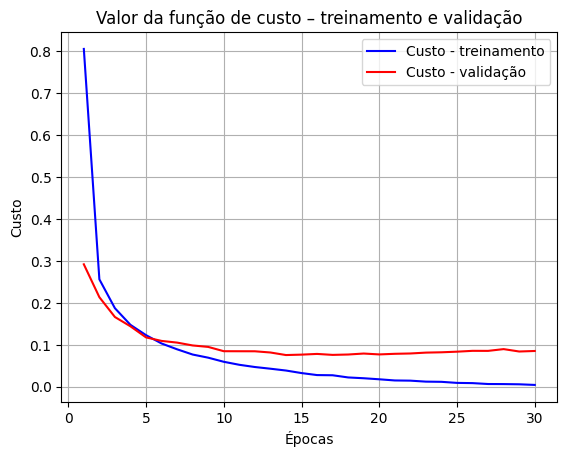

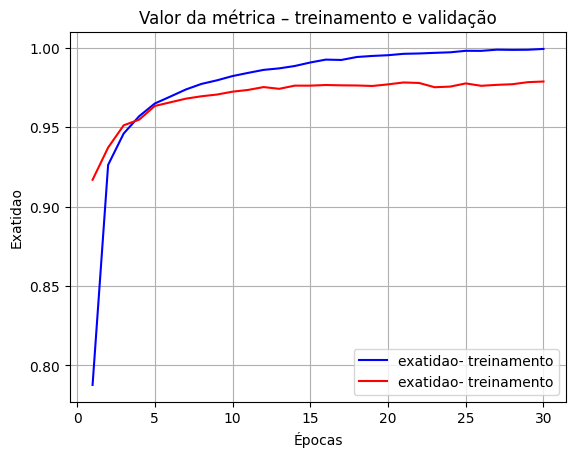

In [ ]:
# def plot_train(history):# Salva treinamento na variável history para visualização
#     history_dict = history.history

#     # Salva custos, métricas e epocas em vetores
#     custo = history_dict['loss']
#     acc = history_dict['sparse_categorical_accuracy']
#     val_custo = history_dict['val_loss']
#     val_acc = history_dict['val_sparse_categorical_accuracy']

#     # Cria vetor de épocas
#     epocas = range(1, len(custo) + 1)

#     # Gráfico dos valores de custo
#     plt.plot(epocas, custo, 'b', label='Custo - treinamento')
#     plt.plot(epocas, val_custo, 'r', label='Custo - validação')
#     plt.title('Valor da função de custo – treinamento e validação')
#     plt.xlabel('Épocas')
#     plt.ylabel('Custo')
#     plt.legend()
#     plt.grid()
#     plt.show()

#     # Gráfico dos valores da métrica
#     plt.plot(epocas, acc, 'b', label='exatidao- treinamento')
#     plt.plot(epocas, val_acc, 'r', label='exatidao- treinamento')
#     plt.title('Valor da métrica – treinamento e validação')
#     plt.xlabel('Épocas')
#     plt.ylabel('Exatidao')
#     plt.legend()
#     plt.grid()
#     plt.show()

plot_train(results)

### 6.5 Avaliação da RNA

Para avaliar o desempenho da RNA vamos calcular a função de custo e a métrica e também calcular as saídas previstas e fazer o gráfico das saídas reais e previstas.

In [ ]:
# Calcula função de custo e métrica
rna.evaluate(x_train, y_train)
rna.evaluate(x_test, y_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0027 - sparse_categorical_accuracy: 0.9999
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0929 - sparse_categorical_accuracy: 0.9766


[0.08525995165109634, 0.9787999987602234]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


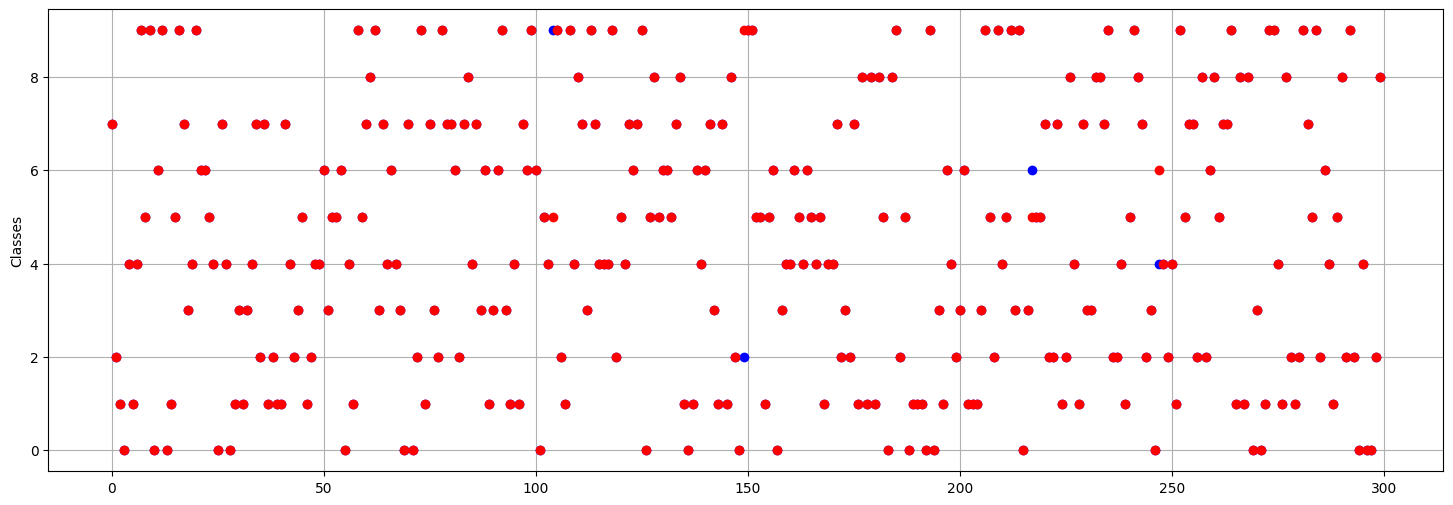

In [ ]:
# Calcula saídas previstas
y_prev = rna.predict(x_test)

# Indentifa classe prevista
class_prev = np.argmax(y_prev, axis=1)

# Gráfico dos resultados
#plt.scatter(x, y)
plt.figure(figsize=(18,6))
plt.plot(y_test[:300], 'bo', label='Saídas reais')
plt.plot(class_prev[:300], 'ro', label='Saídas previstas')
plt.ylabel('Classes')
plt.grid()
plt.show()

Nota-se que os resultados obtidos pela RNA são execelentes, nesses 150 exemplos de teste somente um foi classificado errado.